##📌 EXTRACCIÓN

In [387]:
import pandas as pd

In [388]:
datos = pd.read_csv('/content/datos_limpios.csv')
datos

,id,evasión,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato_meses,servicio_telefono,multiples_lineas,tipo_internet,...,proteccion_dispositivo,soporte_tecnico,streaming_TV,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,facturacion_mensual,facturacion_total,facturacion_diaria
0,0002-ORFBO,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.60,593.30,2.186667
1,0003-MKNFE,No,Masculino,No,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.90,542.40,1.996667
2,0004-TLHLJ,Sí,Masculino,No,No,No,4,Sí,No,Fiber optic,...,Sí,No,No,No,Mensual,Sí,Cheque electrónico,73.90,280.85,2.463333
3,0011-IGKFF,Sí,Masculino,Sí,Sí,No,13,Sí,No,Fiber optic,...,Sí,No,Sí,Sí,Mensual,Sí,Cheque electrónico,98.00,1237.85,3.266667
4,0013-EXCHZ,Sí,Femenino,Sí,Sí,No,3,Sí,No,Fiber optic,...,No,Sí,Sí,No,Mensual,Sí,Cheque enviado por correo,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Femenino,No,No,No,13,Sí,No,DSL,...,No,Sí,No,No,Anual,No,Cheque enviado por correo,55.15,742.90,1.838333
7028,9992-RRAMN,Sí,Masculino,No,Sí,No,22,Sí,Sí,Fiber optic,...,No,No,No,Sí,Mensual,Sí,Cheque electrónico,85.10,1873.70,2.836667
7029,9992-UJOEL,No,Masculino,No,No,No,2,Sí,No,DSL,...,No,No,No,No,Mensual,Sí,Cheque enviado por correo,50.30,92.75,1.676667
7030,9993-LHIEB,No,Masculino,No,Sí,Sí,67,Sí,No,DSL,...,Sí,Sí,No,Sí,Bienal,No,Cheque enviado por correo,67.85,4627.65,2.261667


In [389]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7032 non-null   object 
 1   evasión                 7032 non-null   object 
 2   genero                  7032 non-null   object 
 3   tiene_+60               7032 non-null   object 
 4   tiene_pareja            7032 non-null   object 
 5   tiene_dependientes      7032 non-null   object 
 6   tiempo_contrato_meses   7032 non-null   int64  
 7   servicio_telefono       7032 non-null   object 
 8   multiples_lineas        7032 non-null   object 
 9   tipo_internet           7032 non-null   object 
 10  seguridad_online        7032 non-null   object 
 11  backup_online           7032 non-null   object 
 12  proteccion_dispositivo  7032 non-null   object 
 13  soporte_tecnico         7032 non-null   object 
 14  streaming_TV            7032 non-null   

##🛠️ Pre procesamiento

In [390]:
datos = datos.drop(columns=['id'])
datos.head(2)

,evasión,genero,tiene_+60,tiene_pareja,tiene_dependientes,tiempo_contrato_meses,servicio_telefono,multiples_lineas,tipo_internet,seguridad_online,...,proteccion_dispositivo,soporte_tecnico,streaming_TV,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,facturacion_mensual,facturacion_total,facturacion_diaria
0,No,Femenino,No,Sí,Sí,9,Sí,No,DSL,No,...,No,Sí,Sí,No,Anual,Sí,Cheque enviado por correo,65.6,593.3,2.186667
1,No,Masculino,No,No,No,9,Sí,Sí,DSL,No,...,No,No,No,Sí,Mensual,No,Cheque enviado por correo,59.9,542.4,1.996667


In [391]:
for col in datos.columns:
    print(col)
    print(datos[col].unique())
    print('-'*50)

evasión
['No' 'Sí']
--------------------------------------------------
genero
['Femenino' 'Masculino']
--------------------------------------------------
tiene_+60
['No' 'Sí']
--------------------------------------------------
tiene_pareja
['Sí' 'No']
--------------------------------------------------
tiene_dependientes
['Sí' 'No']
--------------------------------------------------
tiempo_contrato_meses
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
--------------------------------------------------
servicio_telefono
['Sí' 'No']
--------------------------------------------------
multiples_lineas
['No' 'Sí' 'Sin servicio de teléfono']
--------------------------------------------------
tipo_internet
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
seguridad_online
['No' 'Sí' 'Sin servicio 

In [392]:
datos = datos.replace({'Sin servicio de teléfono': 'No', 'Sin servicio de internet': 'No'})

## 0. Encoding

In [393]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [394]:
columnas = datos.columns

In [395]:
categoricas = ['evasión', 'genero', 'tiene_+60', 'tiene_pareja', 'tiene_dependientes','servicio_telefono',
               'multiples_lineas', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo',
               'soporte_tecnico', 'streaming_TV', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago']

In [396]:
one_hot_encoding = make_column_transformer((OneHotEncoder(drop='if_binary'), categoricas), remainder = 'passthrough', sparse_threshold=0)

In [397]:
datos = one_hot_encoding.fit_transform(datos)

In [398]:
one_hot_encoding.get_feature_names_out(columnas)

array(['onehotencoder__evasión_Sí', 'onehotencoder__genero_Masculino',
       'onehotencoder__tiene_+60_Sí', 'onehotencoder__tiene_pareja_Sí',
       'onehotencoder__tiene_dependientes_Sí',
       'onehotencoder__servicio_telefono_Sí',
       'onehotencoder__multiples_lineas_Sí',
       'onehotencoder__tipo_internet_DSL',
       'onehotencoder__tipo_internet_Fiber optic',
       'onehotencoder__tipo_internet_No',
       'onehotencoder__seguridad_online_Sí',
       'onehotencoder__backup_online_Sí',
       'onehotencoder__proteccion_dispositivo_Sí',
       'onehotencoder__soporte_tecnico_Sí',
       'onehotencoder__streaming_TV_Sí',
       'onehotencoder__streaming_peliculas_Sí',
       'onehotencoder__tipo_contrato_Anual',
       'onehotencoder__tipo_contrato_Bienal',
       'onehotencoder__tipo_contrato_Mensual',
       'onehotencoder__factura_digital_Sí',
       'onehotencoder__metodo_pago_Cheque electrónico',
       'onehotencoder__metodo_pago_Cheque enviado por correo',
       'one

In [399]:
datos_codificados = pd.DataFrame(datos, columns=one_hot_encoding.get_feature_names_out(columnas))
datos_codificados.head(2)

,onehotencoder__evasión_Sí,onehotencoder__genero_Masculino,onehotencoder__tiene_+60_Sí,onehotencoder__tiene_pareja_Sí,onehotencoder__tiene_dependientes_Sí,onehotencoder__servicio_telefono_Sí,onehotencoder__multiples_lineas_Sí,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fiber optic,onehotencoder__tipo_internet_No,...,onehotencoder__tipo_contrato_Mensual,onehotencoder__factura_digital_Sí,onehotencoder__metodo_pago_Cheque electrónico,onehotencoder__metodo_pago_Cheque enviado por correo,onehotencoder__metodo_pago_Tarjeta de crédito (automático),onehotencoder__metodo_pago_Transferencia bancaria (automático),remainder__tiempo_contrato_meses,remainder__facturacion_mensual,remainder__facturacion_total,remainder__facturacion_diaria
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,9.0,65.6,593.3,2.186667
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.9,542.4,1.996667


In [400]:
datos_codificados.columns = datos_codificados.columns.str.split('__').str[1]
datos_codificados.head(2)

,evasión_Sí,genero_Masculino,tiene_+60_Sí,tiene_pareja_Sí,tiene_dependientes_Sí,servicio_telefono_Sí,multiples_lineas_Sí,tipo_internet_DSL,tipo_internet_Fiber optic,tipo_internet_No,...,tipo_contrato_Mensual,factura_digital_Sí,metodo_pago_Cheque electrónico,metodo_pago_Cheque enviado por correo,metodo_pago_Tarjeta de crédito (automático),metodo_pago_Transferencia bancaria (automático),tiempo_contrato_meses,facturacion_mensual,facturacion_total,facturacion_diaria
0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,9.0,65.6,593.3,2.186667
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,59.9,542.4,1.996667


In [401]:
datos_codificados.columns

Index(['evasión_Sí', 'genero_Masculino', 'tiene_+60_Sí', 'tiene_pareja_Sí',
       'tiene_dependientes_Sí', 'servicio_telefono_Sí', 'multiples_lineas_Sí',
       'tipo_internet_DSL', 'tipo_internet_Fiber optic', 'tipo_internet_No',
       'seguridad_online_Sí', 'backup_online_Sí', 'proteccion_dispositivo_Sí',
       'soporte_tecnico_Sí', 'streaming_TV_Sí', 'streaming_peliculas_Sí',
       'tipo_contrato_Anual', 'tipo_contrato_Bienal', 'tipo_contrato_Mensual',
       'factura_digital_Sí', 'metodo_pago_Cheque electrónico',
       'metodo_pago_Cheque enviado por correo',
       'metodo_pago_Tarjeta de crédito (automático)',
       'metodo_pago_Transferencia bancaria (automático)',
       'tiempo_contrato_meses', 'facturacion_mensual', 'facturacion_total',
       'facturacion_diaria'],
      dtype='object')

## 1. Eliminación de columnas numéricas

In [402]:
import seaborn as sns
import matplotlib.pyplot as plt

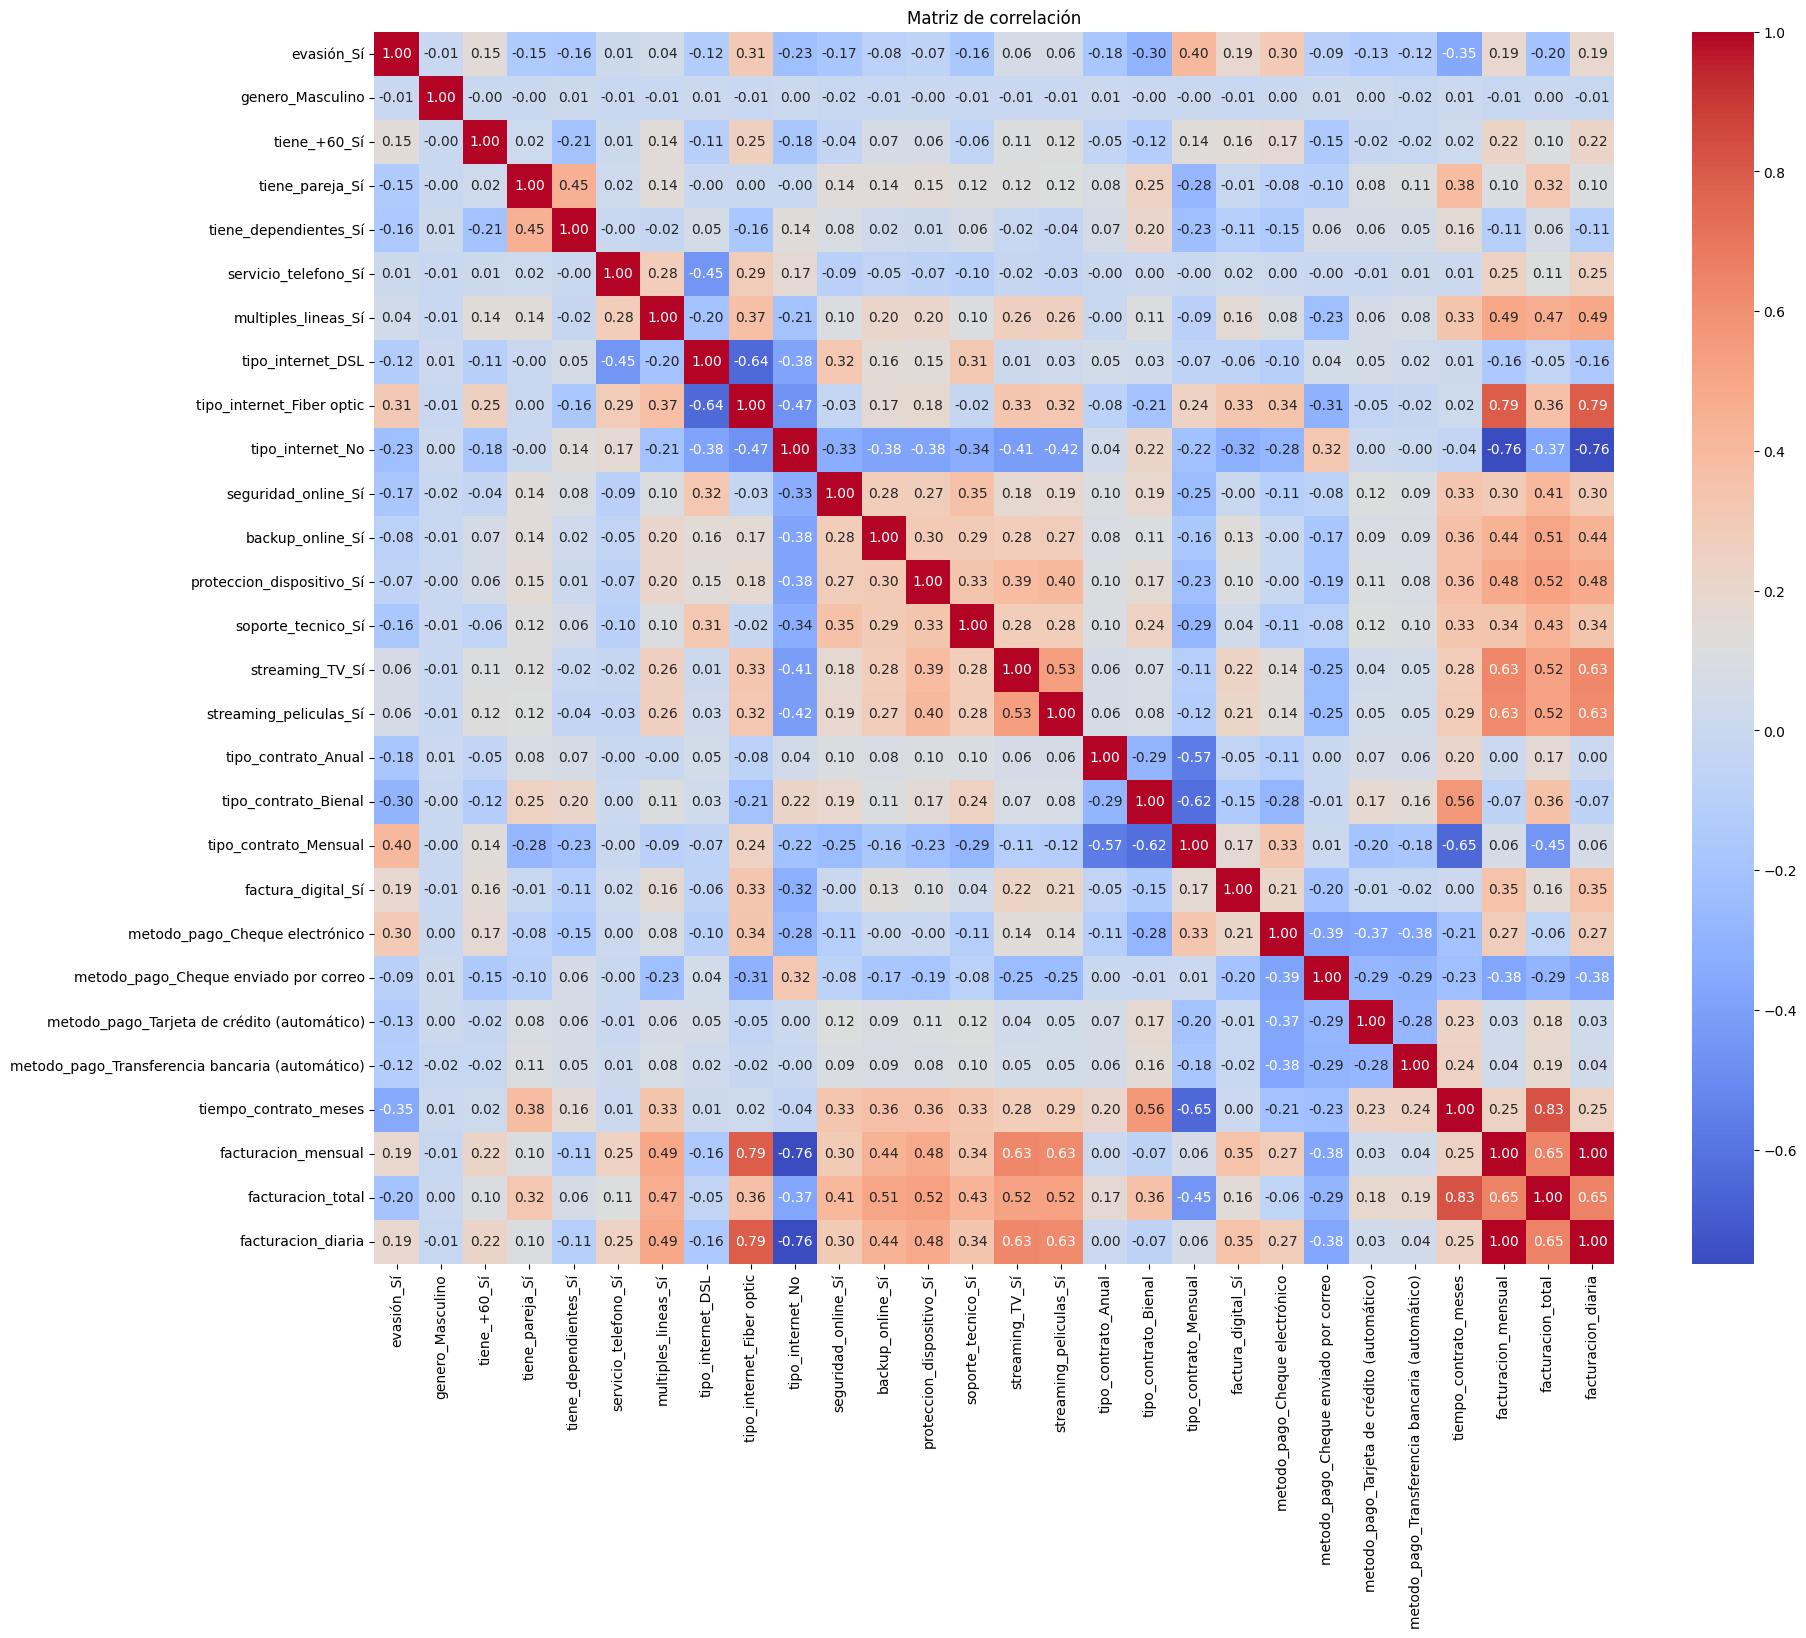

In [403]:
corr = datos_codificados.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt = ".2f")

plt.title("Matriz de correlación")
plt.show()

In [404]:
numericas = ['evasión_Sí', 'tiempo_contrato_meses', 'facturacion_mensual', 'facturacion_total', 'facturacion_diaria']

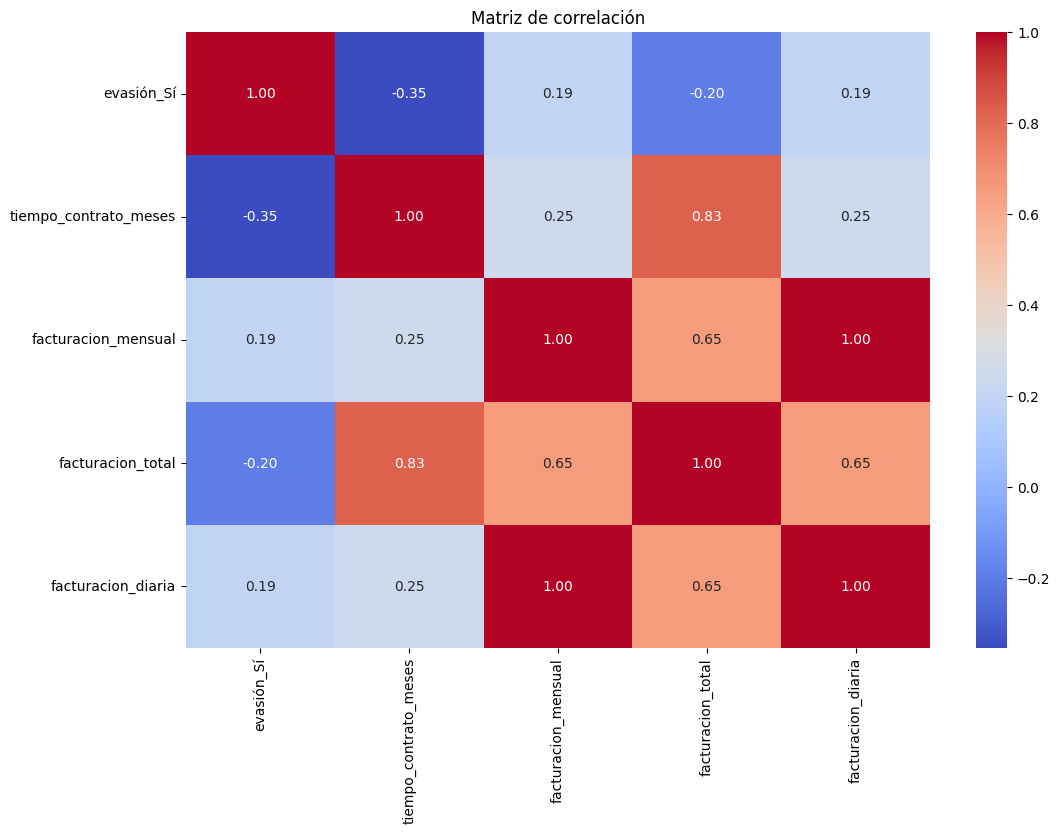

In [405]:
corr = datos_codificados[numericas].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt = ".2f")

plt.title("Matriz de correlación")
plt.show()

In [406]:
datos_codificados = datos_codificados.drop(columns=['facturacion_diaria', 'facturacion_total'])

In [407]:
datos_codificados.columns

Index(['evasión_Sí', 'genero_Masculino', 'tiene_+60_Sí', 'tiene_pareja_Sí',
       'tiene_dependientes_Sí', 'servicio_telefono_Sí', 'multiples_lineas_Sí',
       'tipo_internet_DSL', 'tipo_internet_Fiber optic', 'tipo_internet_No',
       'seguridad_online_Sí', 'backup_online_Sí', 'proteccion_dispositivo_Sí',
       'soporte_tecnico_Sí', 'streaming_TV_Sí', 'streaming_peliculas_Sí',
       'tipo_contrato_Anual', 'tipo_contrato_Bienal', 'tipo_contrato_Mensual',
       'factura_digital_Sí', 'metodo_pago_Cheque electrónico',
       'metodo_pago_Cheque enviado por correo',
       'metodo_pago_Tarjeta de crédito (automático)',
       'metodo_pago_Transferencia bancaria (automático)',
       'tiempo_contrato_meses', 'facturacion_mensual'],
      dtype='object')

## 2. Eliminación de columna 'tipo_internet_No'

In [408]:
datos_codificados['tipo_internet_No'].value_counts()

,count
tipo_internet_No,
0.0,5512
1.0,1520


In [409]:
datos_codificados = datos_codificados.drop(columns=['tipo_internet_No'])

## 3. Eliminación de columnas categoricas

In [410]:
columnas_cat = ['genero_Masculino', 'tiene_+60_Sí', 'tiene_pareja_Sí', 'tiene_dependientes_Sí', 'servicio_telefono_Sí', 'multiples_lineas_Sí',
                'tipo_internet_DSL', 'tipo_internet_Fiber optic', 'seguridad_online_Sí', 'backup_online_Sí', 'proteccion_dispositivo_Sí',
                'soporte_tecnico_Sí', 'streaming_TV_Sí', 'streaming_peliculas_Sí', 'tipo_contrato_Anual', 'tipo_contrato_Bienal',
                'tipo_contrato_Mensual', 'factura_digital_Sí', 'metodo_pago_Cheque electrónico', 'metodo_pago_Cheque enviado por correo',
                'metodo_pago_Tarjeta de crédito (automático)', 'metodo_pago_Transferencia bancaria (automático)']

In [411]:
from sklearn.feature_selection import chi2

In [413]:
X_cat = datos_codificados[columnas_cat]
y = datos_codificados['evasión_Sí']

chi_scores, p_values = chi2(X_cat, y)

df_chi = pd.DataFrame({'Variable': columnas_cat, 'Chi2 Score': chi_scores, 'p-value': p_values})

df_chi = df_chi.sort_values(by='Chi2 Score', ascending=False)

df_chi

,Variable,Chi2 Score,p-value
16,tipo_contrato_Mensual,516.714004,2.195119e-114
15,tipo_contrato_Bienal,486.223101,9.454286e-108
18,metodo_pago_Cheque electrónico,424.113152,3.105849e-94
7,tipo_internet_Fiber optic,372.082851,6.587130e-83
14,tipo_contrato_Anual,176.608724,2.666317e-40
8,seguridad_online_Sí,147.165601,7.219883e-34
11,soporte_tecnico_Sí,135.439602,2.645952e-31
1,tiene_+60_Sí,133.482766,7.089546e-31
3,tiene_dependientes_Sí,131.271509,2.159540e-30
17,factura_digital_Sí,104.979224,1.234232e-24


In [414]:
var_cat_significativas = df_chi[df_chi['p-value'] < 0.05]

display(var_cat_significativas)

,Variable,Chi2 Score,p-value
16,tipo_contrato_Mensual,516.714004,2.195119e-114
15,tipo_contrato_Bienal,486.223101,9.454286e-108
18,metodo_pago_Cheque electrónico,424.113152,3.105849e-94
7,tipo_internet_Fiber optic,372.082851,6.587130e-83
14,tipo_contrato_Anual,176.608724,2.666317e-40
8,seguridad_online_Sí,147.165601,7.219883e-34
11,soporte_tecnico_Sí,135.439602,2.645952e-31
1,tiene_+60_Sí,133.482766,7.089546e-31
3,tiene_dependientes_Sí,131.271509,2.159540e-30
17,factura_digital_Sí,104.979224,1.234232e-24


In [415]:
datos_codificados = datos_codificados.drop(columns=['genero_Masculino', 'servicio_telefono_Sí'])

In [370]:
datos_codificados.columns

Index(['evasión_Sí', 'tiene_+60_Sí', 'tiene_pareja_Sí',
       'tiene_dependientes_Sí', 'multiples_lineas_Sí', 'tipo_internet_DSL',
       'tipo_internet_Fiber optic', 'seguridad_online_Sí', 'backup_online_Sí',
       'proteccion_dispositivo_Sí', 'soporte_tecnico_Sí', 'streaming_TV_Sí',
       'streaming_peliculas_Sí', 'tipo_contrato_Anual', 'tipo_contrato_Bienal',
       'tipo_contrato_Mensual', 'factura_digital_Sí',
       'metodo_pago_Cheque electrónico',
       'metodo_pago_Cheque enviado por correo',
       'metodo_pago_Tarjeta de crédito (automático)',
       'metodo_pago_Transferencia bancaria (automático)',
       'tiempo_contrato_meses', 'facturacion_mensual'],
      dtype='object')